In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import pandas as pd

from src.feature_engineering import create_features
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [3]:
customers = pd.read_csv(
    "../data/raw/customers.csv"
)

df = create_features(customers)

In [4]:
features = [
    "age",
    "income",
    "tenure_years",
    "account_balance",
    "savings_balance",
    "monthly_app_logins",
    "monthly_transactions",
    "complaints",
    "customer_satisfaction",
    "balance_change_pct",
    "total_balance",
    #"savings_ratio", this has a divide by zero error, so we will not use it for now
    "transactions_per_login",
    "has_complaint",
    "balance_declining"
]

In [5]:
X = df[features]
y = df["churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X = df[features]
y = df["churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42))
])

logistic_model.fit(X_train, y_train)

from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [6]:
y_pred = logistic_model.predict(X_test)

y_probability = logistic_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probability)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"ROC-AUC:   {roc_auc:.3f}")

print(classification_report(y_test, y_pred))

print("Training customers:", len(X_train))
print("Testing customers:", len(X_test))
print("Churn rate in training:", y_train.mean())
print("Churn rate in testing:", y_test.mean())

Accuracy:  0.813
Precision: 0.635
Recall:    0.290
ROC-AUC:   0.802
              precision    recall  f1-score   support

           0       0.83      0.95      0.89      3147
           1       0.63      0.29      0.40       853

    accuracy                           0.81      4000
   macro avg       0.73      0.62      0.64      4000
weighted avg       0.79      0.81      0.78      4000

Training customers: 16000
Testing customers: 4000
Churn rate in training: 0.21325
Churn rate in testing: 0.21325


In [7]:
tree_pred = decision_tree.predict(X_test)

tree_probability = decision_tree.predict_proba(X_test)[:, 1]

tree_accuracy = accuracy_score(y_test, tree_pred)
tree_precision = precision_score(y_test, tree_pred)
tree_recall = recall_score(y_test, tree_pred)
tree_roc_auc = roc_auc_score(y_test, tree_probability)

print(f"Accuracy:  {tree_accuracy:.3f}")
print(f"Precision: {tree_precision:.3f}")
print(f"Recall:    {tree_recall:.3f}")
print(f"ROC-AUC:   {tree_roc_auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, tree_pred))

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy,
        tree_accuracy
    ],
    "Precision": [
        precision,
        tree_precision
    ],
    "Recall": [
        recall,
        tree_recall
    ],
    "ROC-AUC": [
        roc_auc,
        tree_roc_auc
    ]
})

print(comparison)

Accuracy:  0.802
Precision: 0.608
Recall:    0.202
ROC-AUC:   0.757

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.96      0.88      3147
           1       0.61      0.20      0.30       853

    accuracy                           0.80      4000
   macro avg       0.71      0.58      0.59      4000
weighted avg       0.77      0.80      0.76      4000

                 Model  Accuracy  Precision    Recall   ROC-AUC
0  Logistic Regression     0.813   0.634961  0.289566  0.801537
1        Decision Tree     0.802   0.607774  0.201641  0.757332


In [8]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

rf_pred = random_forest.predict(X_test)

rf_probability = random_forest.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_probability)

print(f"Accuracy:  {rf_accuracy:.3f}")
print(f"Precision: {rf_precision:.3f}") 
print(f"Recall:    {rf_recall:.3f}")
print(f"ROC-AUC:   {rf_roc_auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        tree_accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        tree_precision,
        rf_precision
    ],
    "Recall": [
        recall,
        tree_recall,
        rf_recall
    ],
    "ROC-AUC": [
        roc_auc,
        tree_roc_auc,
        rf_roc_auc
    ]
})

print(comparison)

Accuracy:  0.810
Precision: 0.637
Recall:    0.251
ROC-AUC:   0.776

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      3147
           1       0.64      0.25      0.36       853

    accuracy                           0.81      4000
   macro avg       0.73      0.61      0.62      4000
weighted avg       0.79      0.81      0.78      4000

                 Model  Accuracy  Precision    Recall   ROC-AUC
0  Logistic Regression   0.81300   0.634961  0.289566  0.801537
1        Decision Tree   0.80200   0.607774  0.201641  0.757332
2        Random Forest   0.80975   0.636905  0.250879  0.775684


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrices
logistic_cm = confusion_matrix(y_test, y_pred)
tree_cm = confusion_matrix(y_test, tree_pred)
rf_cm = confusion_matrix(y_test, rf_pred)

print("Logistic Regression:")
print(logistic_cm)

print("\nDecision Tree:")
print(tree_cm)

print("\nRandom Forest:")
print(rf_cm)



Logistic Regression:
[[3005  142]
 [ 606  247]]

Decision Tree:
[[3036  111]
 [ 681  172]]

Random Forest:
[[3025  122]
 [ 639  214]]


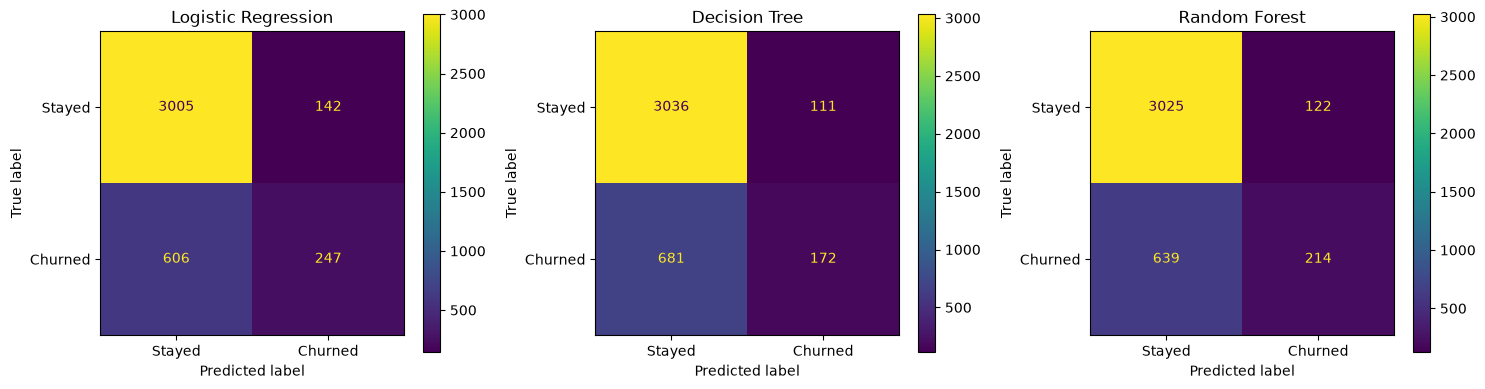

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay(
    logistic_cm,
    display_labels=["Stayed", "Churned"]
).plot(ax=axes[0])

axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(
    tree_cm,
    display_labels=["Stayed", "Churned"]
).plot(ax=axes[1])

axes[1].set_title("Decision Tree")

ConfusionMatrixDisplay(
    rf_cm,
    display_labels=["Stayed", "Churned"]
).plot(ax=axes[2])

axes[2].set_title("Random Forest")

plt.tight_layout()
plt.show()

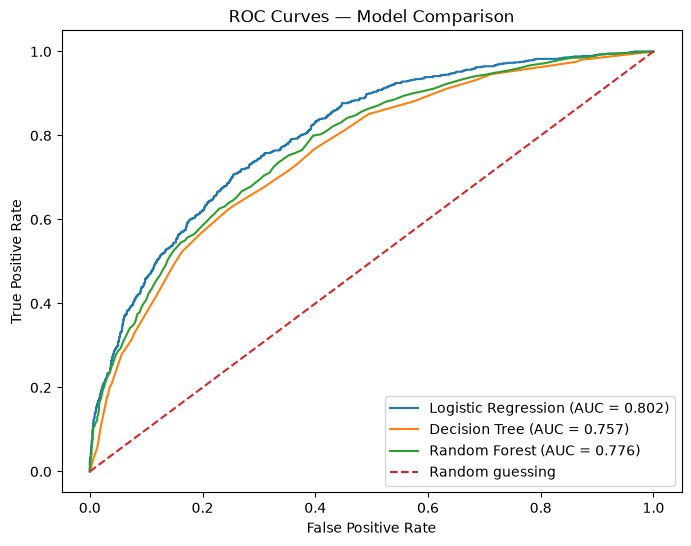

In [11]:
from sklearn.metrics import roc_curve

logistic_fpr, logistic_tpr, _ = roc_curve(y_test, y_probability)
tree_fpr, tree_tpr, _ = roc_curve(y_test, tree_probability)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probability)

plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    tree_fpr,
    tree_tpr,
    label=f"Decision Tree (AUC = {tree_roc_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random guessing")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend()
plt.show()

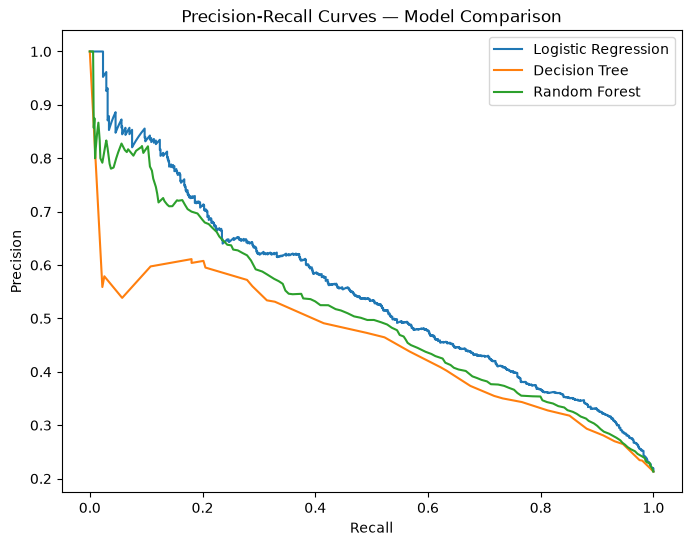

In [12]:
from sklearn.metrics import precision_recall_curve

logistic_precision, logistic_recall, _ = precision_recall_curve(
    y_test,
    y_probability
)

tree_precision, tree_recall, _ = precision_recall_curve(
    y_test,
    tree_probability
)

rf_precision, rf_recall, _ = precision_recall_curve(
    y_test,
    rf_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    logistic_recall,
    logistic_precision,
    label="Logistic Regression"
)

plt.plot(
    tree_recall,
    tree_precision,
    label="Decision Tree"
)

plt.plot(
    rf_recall,
    rf_precision,
    label="Random Forest"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — Model Comparison")
plt.legend()
plt.show()

In [13]:
from sklearn.metrics import precision_score, recall_score

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for threshold in thresholds:

    threshold_pred = (
        y_probability >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    customers_flagged = threshold_pred.sum()

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "Customers Flagged": customers_flagged
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df)

   Threshold  Precision    Recall  Customers Flagged
0        0.1   0.316085  0.923798               2493
1        0.2   0.404487  0.739742               1560
2        0.3   0.481809  0.574443               1017
3        0.4   0.567610  0.423212                636
4        0.5   0.634961  0.289566                389
5        0.6   0.711297  0.199297                239
6        0.7   0.821705  0.124267                129


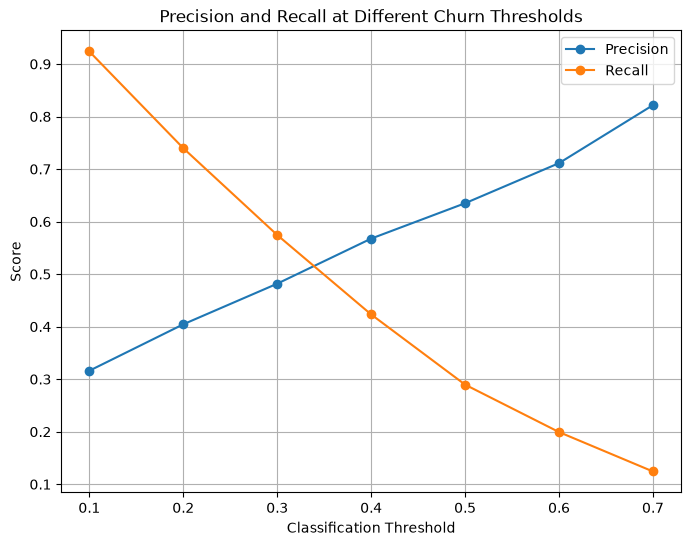

In [14]:
plt.figure(figsize=(8, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall at Different Churn Thresholds")
plt.legend()
plt.grid(True)

plt.show()

In [19]:
# Get the logistic regression model from the pipeline
logistic_coefficients = logistic_model.named_steps["model"].coef_[0]

# Create a table of features and coefficients
coefficient_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": logistic_coefficients
})

# Sort by coefficient
coefficient_df = coefficient_df.sort_values(
    "Coefficient",
    ascending=False
)

#print(coefficient_df)

import numpy as np

coefficient_df["Odds Ratio"] = np.exp(
    coefficient_df["Coefficient"]
)

print(coefficient_df)

                   Feature  Coefficient  Odds Ratio
7               complaints     0.579160    1.784539
1                   income     0.037836    1.038561
12           has_complaint     0.032324    1.032852
3          account_balance     0.012369    1.012446
10           total_balance    -0.006411    0.993610
11  transactions_per_login    -0.010965    0.989095
4          savings_balance    -0.011675    0.988393
13       balance_declining    -0.033473    0.967081
0                      age    -0.205137    0.814536
9       balance_change_pct    -0.274838    0.759695
2             tenure_years    -0.277078    0.757995
6     monthly_transactions    -0.427239    0.652308
5       monthly_app_logins    -0.674194    0.509567
8    customer_satisfaction    -0.791632    0.453105


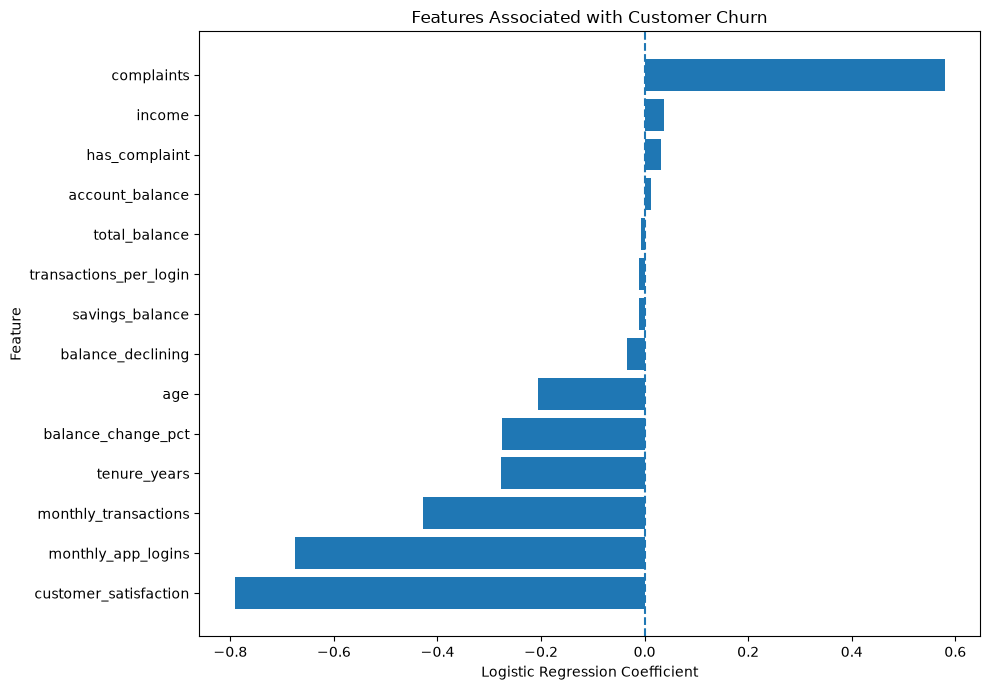

In [20]:
coefficient_plot = coefficient_df.sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 7))

plt.barh(
    coefficient_plot["Feature"],
    coefficient_plot["Coefficient"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Features Associated with Customer Churn")

plt.tight_layout()
plt.show()

In [34]:
# Select one customer from the test set
customer_index = X_test.index[14]

customer = X_test.loc[[customer_index]]

# Get the customer's actual outcome
actual_outcome = y_test.loc[customer_index]

# Predict churn probability
churn_probability = logistic_model.predict_proba(customer)[0, 1]

print(f"Customer index: {customer_index}")
print(f"Actual outcome: {'Churned' if actual_outcome == 1 else 'Stayed'}")
print(f"Predicted churn probability: {churn_probability:.1%}")

print(customer.T)

Customer index: 13915
Actual outcome: Churned
Predicted churn probability: 61.1%
                               13915
age                        28.000000
income                  58444.000000
tenure_years                6.000000
account_balance         13207.290000
savings_balance         38646.540000
monthly_app_logins         14.000000
monthly_transactions       22.000000
complaints                  3.000000
customer_satisfaction       6.900000
balance_change_pct          6.270000
total_balance           51853.830000
transactions_per_login      1.571429
has_complaint               1.000000
balance_declining           0.000000


In [35]:
# Get the scaler and logistic regression model
scaler = logistic_model.named_steps["scaler"]
model = logistic_model.named_steps["model"]

# Standardise the customer's features
customer_scaled = scaler.transform(customer)

# Get model coefficients
coefficients = model.coef_[0]

# Calculate each feature's contribution
contributions = customer_scaled[0] * coefficients

# Create a table
contribution_df = pd.DataFrame({
    "Feature": features,
    "Value": customer.iloc[0].values,
    "Contribution": contributions
})

# Sort by contribution
contribution_df = contribution_df.sort_values(
    "Contribution",
    ascending=False
)

print(contribution_df)

                   Feature         Value  Contribution
7               complaints      3.000000      2.353304
8    customer_satisfaction      6.900000      0.316003
0                      age     28.000000      0.171692
2             tenure_years      6.000000      0.129544
1                   income  58444.000000      0.053966
12           has_complaint      1.000000      0.046117
13       balance_declining      0.000000      0.033435
3          account_balance  13207.290000      0.009355
11  transactions_per_login      1.571429      0.001094
10           total_balance  51853.830000     -0.009542
4          savings_balance  38646.540000     -0.015254
9       balance_change_pct      6.270000     -0.114819
5       monthly_app_logins     14.000000     -0.387851
6     monthly_transactions     22.000000     -0.410387


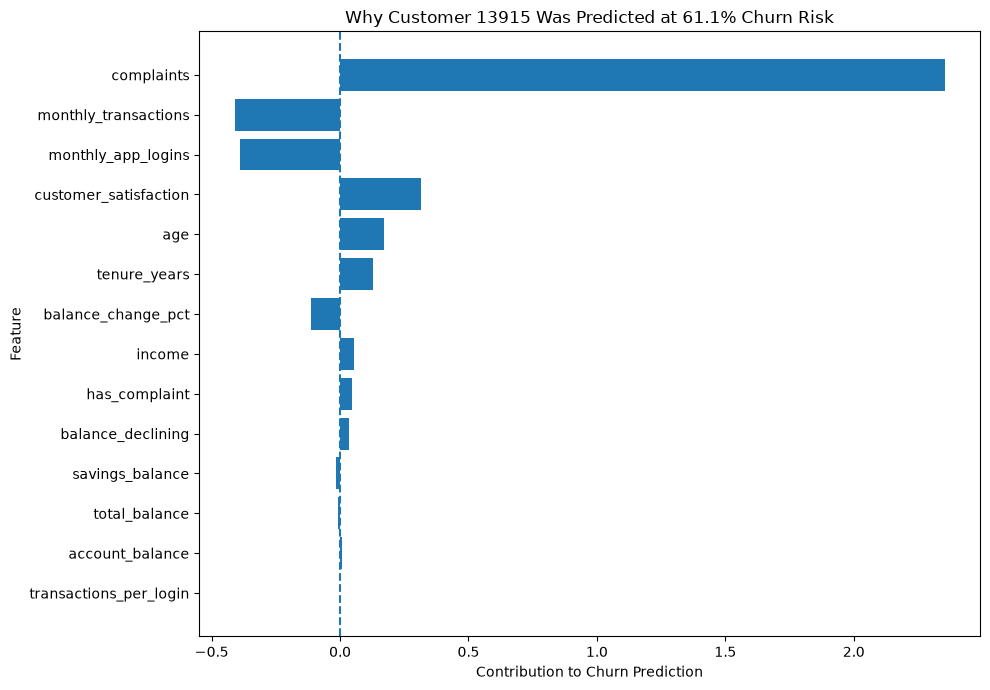

In [36]:
# Sort by absolute contribution so the strongest factors appear first
plot_df = contribution_df.copy()

plot_df["Absolute Contribution"] = (
    plot_df["Contribution"].abs()
)

plot_df = plot_df.sort_values(
    "Absolute Contribution",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["Feature"],
    plot_df["Contribution"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Contribution to Churn Prediction")
plt.ylabel("Feature")
plt.title(
    f"Why Customer {customer_index} Was Predicted "
    f"at {churn_probability:.1%} Churn Risk"
)

plt.tight_layout()
plt.show()